# Pricing with Montecarlo Simulation

## Stochastic R Paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import numpy as np
import math

#prima cosa da dire è che stiamo discretizzando un processo continuo dunque applichiamo euler in modo che r^ converga a r continuo per deltat --> o
m = 250 #giorni di trading in un anno
T = 1 #vediamo in un orizzonte temporale annuale
dt = T/m #delta della discretization che deve essere uniforme DA USARE LO STESSO M E delta_t ANCHE PER LA STOCK PER COERENZA PERCHè S DIPENDE DA R
N_sim= 100
#ora servono i dati di  mkt per rendere il modello più realistico
r0 = 0.0364 #T-Bill americano 27/12, gli altri pesi a caso ma potremmo calcolarli volendo...
theta = 0.04
k = 0.2 # 1/k =  time (in years) that it takes to the precess to go back to theta
sigmar = 0.02

sigmas = 0.25  # volatilità del sottostante S
S0 = 100        # prezzo iniziale dell'azione
K = 100         # strike dell'opzione call
r = np.zeros((N_sim, m+1))
S = np.zeros((N_sim, m+1))
r[:, 0] = r0
S[:, 0] = S0
rho = 0.25
sqrt_dt = np.sqrt(dt)
#prima cosa da dire è che stiamo discretizzando un processo continuo dunque applichiamo euler in modo che r^ converga a r continuo per deltat --> o
m = 250 #giorni di trading in un anno
T = 1 #vediamo in un orizzonte temporale annuale
delta_t = T/m #delta della discretization che deve essere uniforme DA USARE LO STESSO M E delta_t ANCHE PER LA STOCK PER COERENZA PERCHè S DIPENDE DA R
N_sim= 10000

#ora servono i dati di  mkt per rendere il modello più realistico
r0 = 0.0364 #T-Bill americano 27/12, gli altri pesi a caso ma potremmo calcolarli volendo...
theta = 0.04
k = 0.2 # 1/k =  time (in years) that it takes to the precess to go back to theta
sigmar = 0.02
np.random.seed(0)

r = np.zeros(shape=(N_sim,m+1))
r[:,0] = r0
rho = 0.25 #vedi paper su correlazione. storicamente oscilla tra -0.29 e 0.35, abbiamo scelto circa un punto a metà

for j in range(int(N_sim)):
  for i in range(int(m)):
    Z1 = np.random.normal()
    Z2 = np.random.normal()
    r[j, i+1] = r[j, i] +k*(theta-r[j,i])*delta_t +sigmar*np.sqrt(delta_t)*(Z1 * rho + (np.sqrt(1- rho**2) * Z2))


#cose da fare : grafici , ha senso inserire dati reali o calcolarli noi per r, rho e gli altri parametri???



In [2]:
r

array([[0.0364    , 0.03745081, 0.04050688, ..., 0.03356532, 0.03273241,
        0.03232094],
       [0.0364    , 0.03648197, 0.03654463, ..., 0.01971428, 0.01978313,
        0.0189978 ],
       [0.0364    , 0.03767174, 0.03766831, ..., 0.0367683 , 0.03639296,
        0.03591463],
       ...,
       [0.0364    , 0.03583215, 0.03682903, ..., 0.06479487, 0.06439159,
        0.06414181],
       [0.0364    , 0.03357001, 0.03233118, ..., 0.02547698, 0.02445331,
        0.02382455],
       [0.0364    , 0.03778986, 0.03711529, ..., 0.04611018, 0.0461041 ,
        0.04721867]])

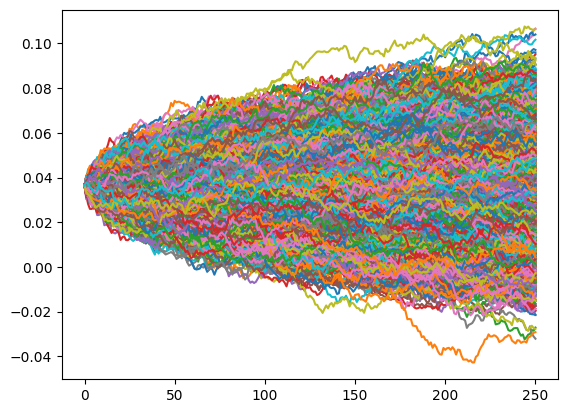

In [3]:
for j in range(int(N_sim)):
    plt.plot(r[j,:])


# Montecarlo Pricing

In [4]:
import numpy as np

# Parametri del modello
sigmas = 0.25  # volatilità del sottostante S
S0 = 100        # prezzo iniziale dell'azione
K = 100         # strike dell'opzione call
T = 1.0         # orizzonte (1 anno)
m = 250         # numero di step di tempo

N_sim = 10000   # numero di simulazioni Monte Carlo

# Parameters from Part 1, for self-containment
r0 = 0.0364 # T-Bill americano 27/12
theta = 0.04
k = 0.2 # 1/k =  time (in years) that it takes to the precess to go back to theta
sigmar = 0.02
rho = 0.25 # correlation


delta_t = T/m # delta della discretization




r = np.zeros(shape=(N_sim,m+1))
r[:,0] = r0
rho = 0.25 #vedi paper su correlazione. storicamente oscilla tra -0.29 e 0.35, abbiamo scelto circa un punto a metà
S = np.zeros(shape=(N_sim,m+1))
S[:,0] = S0


for j in range(int(N_sim)):
  for i in range(int(m)):
    Z1 = np.random.normal()
    Z2 = np.random.normal()
    S[j, i+1] = S[j, i] * np.exp((r[j,i] - 0.5*sigmas**2)*delta_t + sigmas*np.sqrt(delta_t)*Z1)
    r[j, i+1] = r[j, i] +k*(theta-r[j,i])*delta_t +sigmar*np.sqrt(delta_t)*(Z1 * rho + (np.sqrt(1- rho**2) * Z2))






In [5]:
r

array([[0.0364    , 0.03746506, 0.03590722, ..., 0.04784596, 0.0492567 ,
        0.04818999],
       [0.0364    , 0.03542559, 0.03508654, ..., 0.0372623 , 0.03644375,
        0.0346584 ],
       [0.0364    , 0.03411167, 0.03430886, ..., 0.02443277, 0.02494957,
        0.02454259],
       ...,
       [0.0364    , 0.03660732, 0.03448679, ..., 0.05232313, 0.05286078,
        0.05349831],
       [0.0364    , 0.03720224, 0.03702736, ..., 0.02455895, 0.02708915,
        0.02739181],
       [0.0364    , 0.03630977, 0.03652558, ..., 0.04538254, 0.04314433,
        0.04212649]])

In [6]:
discount_factor = np.ones(m)
for i in range(m):
  discount_factor[i] = r[:,i].mean()


payoff_call = np.maximum(S[:,-1]-K, 0)
payoff_call = payoff_call.mean()

price_call = payoff_call.mean() * np.exp(-np.sum(discount_factor*delta_t))
price_call

np.float64(12.112112658652839)

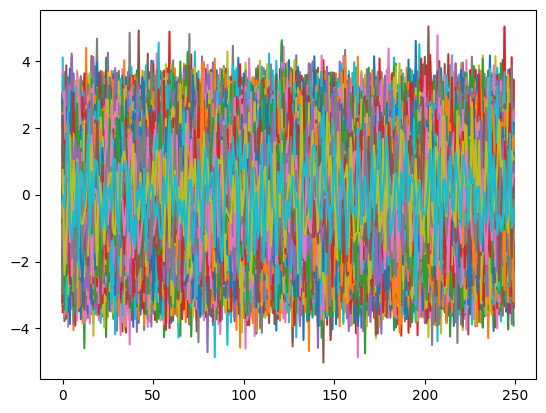

In [9]:
import numpy as np
import matplotlib.pyplot as plt


Z1 = np.random.normal(size=(N_sim, m))
Z2 = np.random.normal(size=(N_sim, m))
for i in range(N_sim):
  plt.plot(Z1[i,:])

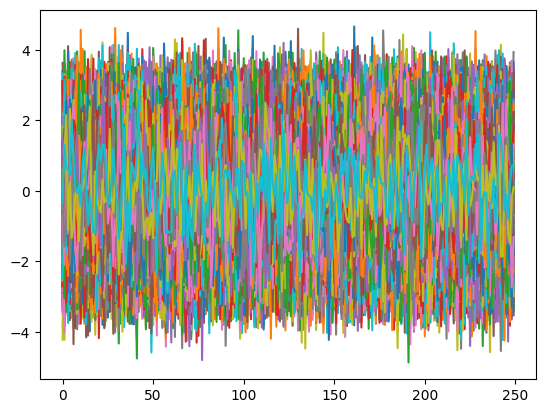

In [12]:
for i in range(N_sim):
  plt.plot(Z2[i,:])

In [10]:
# Eseguiamo la simulazione Monte Carlo
import numpy as np

r0 = 0.0364; theta = 0.04; k = 0.2; sigmar = 0.02
rho = 0.25; sigma_S = 0.25; S0 = 100; K = 100
T = 1.0; m = 250; delta_t = T/m
N_sim = 10000
np.random.seed(0)

Z1 = np.random.normal(size=(N_sim, m))
Z2 = np.random.normal(size=(N_sim, m))

r = np.full(N_sim, r0)
S = np.full(N_sim, S0)
discount_factor = np.ones(N_sim)
sqrt_delta_t = np.sqrt(delta_t)
for j in range(m):
    dW_r = sqrt_delta_t * Z1[:, j]
    dW_S = sqrt_delta_t * (rho * Z1[:, j] + np.sqrt(1 - rho**2) * Z2[:, j])
    r = r + k * (theta - r) * delta_t + sigmar * dW_r
    S = S + S * r * delta_t + S * sigma_S * dW_S
    discount_factor *= np.exp(-r * delta_t)

payoff = discount_factor * np.maximum(S - K, 0.0)
call_price_mc = payoff.mean()
call_price_mc_se = payoff.std(ddof=1) / np.sqrt(N_sim)
print(f"Prezzo Call (Monte Carlo) = {call_price_mc:.4f} ± {call_price_mc_se:.4f} (errore std)")


Prezzo Call (Monte Carlo) = 11.9376 ± 0.1864 (errore std)


## Closed-formula Pricing

In [11]:
import math

r0 = 0.0364
theta = 0.04
k = 0.2
sigmar = 0.02    # σ_r
rho = 0.25
sigma_S = 0.25   # σ_S
S0 = 100
K = 100
T = 1.0

# Calcolo Sigma
Sigma11 = sigma_S**2 * T
Sigma22 = (sigmar**2 / k**2) * ( T - (3 + math.exp(-k*T)*(math.exp(-k*T) - 4)) / (2 * k) )
Sigma12 = (sigma_S * sigmar * rho / k) * ( (math.exp(-k*T) - 1) / k + T )

# calcolo di B(T) per Vasicek in misura RN (lambda=0)
B_T = -(1/k) * ( (r0 - theta) * (math.exp(-k*T) - 1) - k * theta * T )

# calcolo di C(T), D, d1_tilde, d2_tilde
C_T = Sigma11/2 - B_T + math.log(K/S0)
D = Sigma11 + 2*Sigma12 + Sigma22
sqrtD = math.sqrt(D)
d1_tilde = (Sigma11 + Sigma12 - C_T) / sqrtD
d2_tilde = d1_tilde - sqrtD

# calcolo del prezzo del bond P(0,T) = E[exp(-∫0^T r_s ds)] Vasicek
P_0T = math.exp(0.5 * Sigma22 - B_T)

# call formula chiusa
from math import erf, sqrt
Phi = lambda x: 0.5 * (1 + math.erf(x / math.sqrt(2)))   # funzione di ripartizione N(x)
call_price_closed = S0 * Phi(d1_tilde) - K * P_0T * Phi(d2_tilde)

print(f"Prezzo Call (formula chiusa) = {call_price_closed:.4f}")


Prezzo Call (formula chiusa) = 11.7720
